# Logistic Regression

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO

import torch
import torch.nn.functional as F

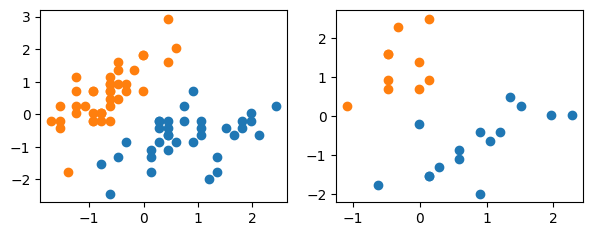

In [8]:
ds = np.lib.DataSource()
fp = ds.open('http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data')

x = np.genfromtxt(BytesIO(fp.read().encode()), delimiter=',', usecols=range(2), max_rows=100)
y = np.zeros(100)
y[50:] = 1

np.random.seed(1)
idx = np.arange(y.shape[0])
np.random.shuffle(idx)
X_test, y_test = x[idx[:25]], y[idx[:25]]
X_train, y_train = x[idx[25:]], y[idx[25:]]
mu, std = np.mean(X_train, axis=0), np.std(X_train, axis=0)
X_train, X_test = (X_train - mu) / std, (X_test - mu) / std

fig, ax = plt.subplots(1, 2, figsize=(7, 2.5))
ax[0].scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1])
ax[0].scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1])
ax[1].scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1])
ax[1].scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1])
plt.show()

# Create model

In [9]:
class LogisticRegression3(torch.nn.Module):

    def __init__(self, num_features):
        super(LogisticRegression3, self).__init__()
        self.linear = torch.nn.Linear(num_features, 1)
        # initialize weights to zeros here,
        # since we used zero weights in the
        # manual approach
        
        self.linear.weight.detach().zero_()
        self.linear.bias.detach().zero_()
        # Note: the trailing underscore
        # means "in-place operation" in the context
        # of PyTorch
        
    def forward(self, x):
        logits = self.linear(x)
        probas = torch.sigmoid(logits)
        return probas

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = LogisticRegression3(num_features=2).to(device)

In [10]:
##### Define cost function and set up optimizer #####
cost_fn = torch.nn.BCELoss(reduction='sum')
# average_size=False to match results in
# manual approach, where we did not normalize
# the cost by the batch size
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [11]:
def custom_where(cond, x_1, x_2):
    return (cond * x_1) + ((1-cond) * x_2)

def comp_accuracy(label_var, pred_probas):
    pred_labels = custom_where((pred_probas > 0.5).float(), 1, 0).view(-1)
    acc = torch.sum(pred_labels == label_var.view(-1)).float() / label_var.size(0)
    return acc


num_epochs = 10

X_train_tensor = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device=device).view(-1, 1)


for epoch in range(num_epochs):
    
    #### Compute outputs ####
    out = model(X_train_tensor)
    
    #### Compute gradients ####
    cost = cost_fn(out, y_train_tensor)
    optimizer.zero_grad()
    cost.backward()
    
    #### Update weights ####  
    optimizer.step()
    
    #### Logging ####      
    pred_probas = model(X_train_tensor)
    acc = comp_accuracy(y_train_tensor, pred_probas)
    print('Epoch: %03d' % (epoch + 1), end="")
    print(' | Train ACC: %.3f' % acc, end="")
    print(' | Cost: %.3f' % cost_fn(pred_probas, y_train_tensor))


    
print('\nModel parameters:')
print('  Weights: %s' % model.linear.weight)
print('  Bias: %s' % model.linear.bias)

Epoch: 001 | Train ACC: 0.987 | Cost: 5.581
Epoch: 002 | Train ACC: 0.987 | Cost: 4.881
Epoch: 003 | Train ACC: 1.000 | Cost: 4.383
Epoch: 004 | Train ACC: 1.000 | Cost: 3.998
Epoch: 005 | Train ACC: 1.000 | Cost: 3.694
Epoch: 006 | Train ACC: 1.000 | Cost: 3.442
Epoch: 007 | Train ACC: 1.000 | Cost: 3.233
Epoch: 008 | Train ACC: 1.000 | Cost: 3.050
Epoch: 009 | Train ACC: 1.000 | Cost: 2.895
Epoch: 010 | Train ACC: 1.000 | Cost: 2.759

Model parameters:
  Weights: Parameter containing:
tensor([[ 4.2264, -2.9618]], device='cuda:0', requires_grad=True)
  Bias: Parameter containing:
tensor([0.0993], device='cuda:0', requires_grad=True)
